# Wind Spectrum Analysis
## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow

## Reading In Datasets

In [3]:
# load in turbine and met masts datasets
scada = pd.read_parquet('../../data/cleaned/scada_data.parquet')
metmasts = pd.read_parquet('../../data/cleaned/metmasts_data.parquet')

In [4]:
# extracting unique turbines
scada['turbine'].unique()

<ArrowStringArray>
['WTG150', 'WTG151', 'WTG152', 'WTG153', 'WTG154', 'WTG155', 'WTG156',
 'WTG157', 'WTG158', 'WTG159', 'WTG161', 'WTG162', 'WTG163', 'WTG164',
 'WTG165', 'WTG166', 'WTG167', 'WTG168', 'WTG169', 'WTG170', 'WTG171',
 'WTG172', 'WTG173', 'WTG174', 'WTG175', 'WTG176', 'WTG177', 'WTG178',
 'WTG179', 'WTG180', 'WTG181', 'WTG182', 'WTG183', 'WTG184', 'WTG185',
 'WTG186', 'WTG187', 'WTG188', 'WTG189', 'WTG190', 'WTG191', 'WTG192',
 'WTG193', 'WTG194', 'WTG195', 'WTG196', 'WTG197']
Length: 47, dtype: str

## Individual Turbines Wind Speed Distributions

In [83]:
# creating a function to create wind speed distributions
def wind_spectrum(df, turbine, xlim = None, bins = 50):
    new = df[df['turbine'] == turbine]
    avg = new['wind_speed'].mean()
    
    new['wind_speed'].plot.hist(bins = bins, color = 'cornflowerblue', figsize = (8, 4))

    if xlim is not None:
        plt.xlim(0, xlim)
    
    plt.axvline(avg, color = 'dimgray', linestyle = '--')
    plt.text(avg, plt.ylim()[1] * 0.8, f' Mean = {avg:.2f}', color = 'dimgray', va = 'top')
    plt.title(f'Distribution of Wind Speeds: Turbine {turbine}')
    plt.xlabel('Wind Speeds')
    plt.ylabel('Counts')
    plt.show()

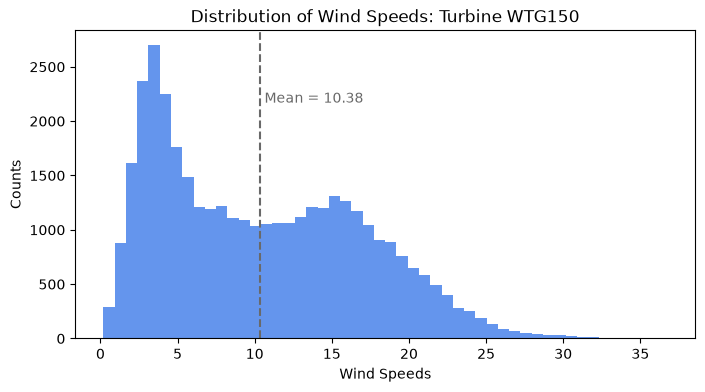

In [84]:
# creating spectrum for WTG150
wind_spectrum(scada, 'WTG150')

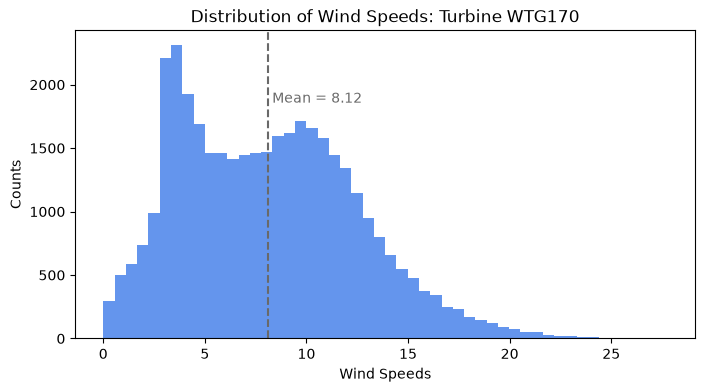

In [87]:
# creating spectrum for WTG170
wind_spectrum(scada, 'WTG170')

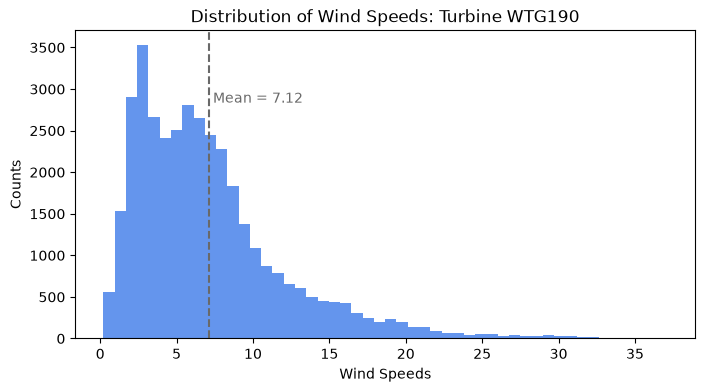

In [86]:
# creating spectrum for WTG190
wind_spectrum(scada, 'WTG190')

### Full Dataset Spectrum

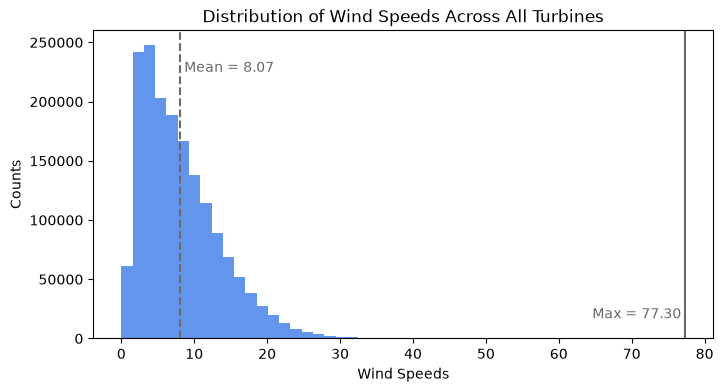

In [76]:
# defining mean and max for the dataset
wind_max = scada['wind_speed'].max()
wind_mean = scada['wind_speed'].mean()

# plotting full dataset spectrum
scada['wind_speed'].plot.hist(bins = 50, color = 'cornflowerblue', figsize = (8, 4))
plt.axvline(wind_max, color = 'dimgray', linestyle = '-')
plt.text(wind_max - 0.5, plt.ylim()[1] * 0.1, f' Max = {wind_max:.2f}', color = 'dimgray', va = 'top', ha = 'right')
plt.axvline(wind_mean, color = 'dimgray', linestyle = '--')
plt.text(wind_mean, plt.ylim()[1] * 0.9, f' Mean = {wind_mean:.2f}', color = 'dimgray', va = 'top')
plt.title('Distribution of Wind Speeds Across All Turbines')
plt.xlabel('Wind Speeds')
plt.ylabel('Counts')
plt.show()

In [95]:
# analyzing the top wind speeds
scada.sort_values('wind_speed', ascending = False).head(10)

,utc,turbine,air_density,KPI_temp_ambient_merged,KPI_temp_ambient,KPI_theoretical_power,KPI_real_power_ac,real_power_ac,KPI_wind_speed,wind_speed,wind_direction,wind_direction_relative,nacelle_pos,blade_1_pos,blade_2_pos,blade_3_pos,blade_1_setpos,blade_2_setpos,blade_3_setpos
849573,2026-05-06 20:40:00,WTG151,1.023593,29.185045,29.185045,0.0,0.0,NaN,77.304800,77.304967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849338,2026-05-06 19:50:00,WTG151,1.025459,28.475374,28.475374,0.0,0.0,NaN,77.301270,77.300193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849244,2026-05-06 19:30:00,WTG151,1.027612,27.842722,27.842722,0.0,0.0,NaN,77.298676,77.299393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849197,2026-05-06 19:20:00,WTG151,1.027997,27.729841,27.729841,0.0,0.0,NaN,77.298720,77.299041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849291,2026-05-06 19:40:00,WTG151,1.026303,28.227123,28.227123,0.0,0.0,NaN,77.301476,77.298909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
849385,2026-05-06 20:00:00,WTG151,0.736472,28.723799,28.723799,0.0,0.0,NaN,71.687450,74.962870,304.0,0.000000,NaN,NaN,NaN,NaN,90.104813,88.592300,89.477974
849479,2026-05-06 20:20:00,WTG151,1.024687,28.861822,28.861822,0.0,0.0,NaN,40.380910,74.543249,259.0,-45.000000,NaN,NaN,NaN,NaN,90.104813,88.592300,89.477974
849432,2026-05-06 20:10:00,WTG151,1.033819,26.191227,26.191227,0.0,0.0,NaN,68.358710,74.212660,219.5,-85.000000,304.5,45.052406,44.296150,44.738987,72.747721,71.991465,72.478303
849526,2026-05-06 20:30:00,WTG151,1.035649,25.661602,25.661602,0.0,0.0,NaN,65.784430,73.236181,203.0,-112.666667,304.5,45.052406,44.296150,44.738987,76.145092,75.956028,77.063755
748809,2026-04-21 23:20:00,WTG155,1.066295,15.884567,15.884567,0.0,0.0,NaN,75.383060,63.103691,167.2,-49.800000,NaN,89.000504,89.000366,89.001770,89.000000,89.000000,89.000000


Turbine WTG151 has some very

## Time Series Analysis

In [77]:
# writing a function to create time series
def time_series(df, turbine):
    new = df[df['turbine'] == turbine]
    new_daily = new.resample('D', on = 'utc')['wind_speed'].mean().reset_index()

    start = pd.Timestamp('2026-01-01')
    end = pd.Timestamp('2026-10-01')

    ax = new_daily.plot('utc', 'wind_speed', color = 'cornflowerblue', figsize = (8, 4), legend = False)
    ax.set_xlim(start, end)
    ax.xaxis.set_major_locator(mdates.MonthLocator())        
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.figure.autofmt_xdate()
    ax.set_title(f'Wind Speeds Through 2026: Turbine {turbine}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Average Wind Speed')
    plt.show()

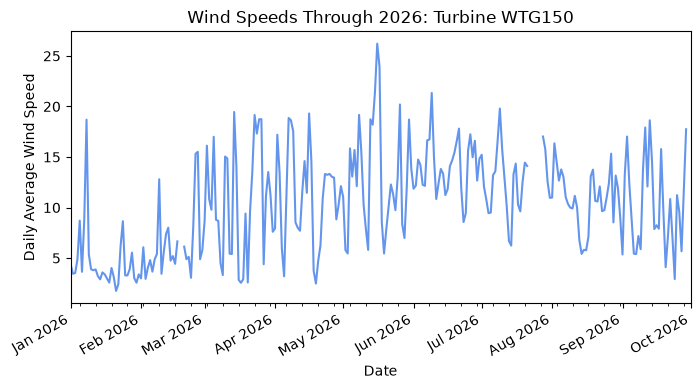

In [88]:
# creating time series for WTG150
time_series(scada, 'WTG150')

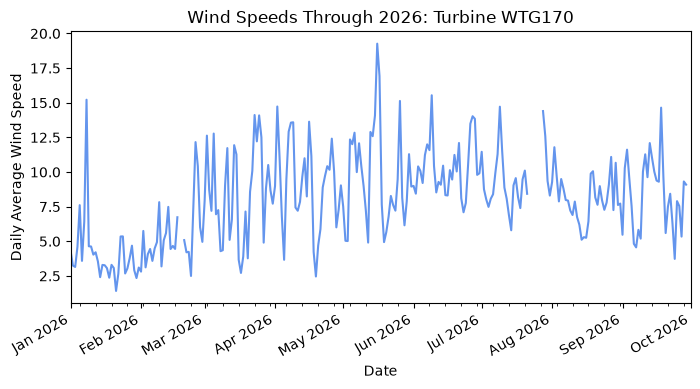

In [89]:
# creating time series for WTG170
time_series(scada, 'WTG170')

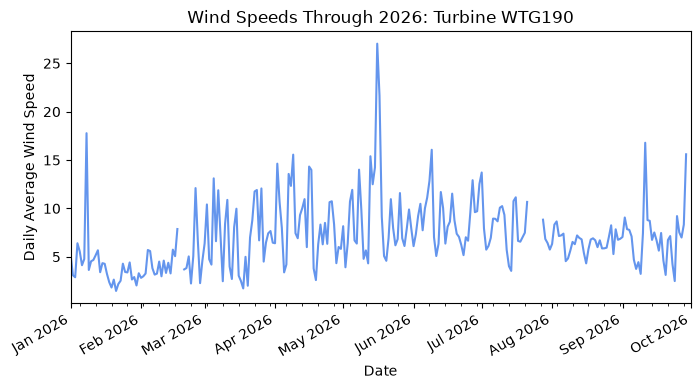

In [90]:
# creating time series for WTG190
time_series(scada, 'WTG190')

Looking at the missing data within the data for WTG150

In [92]:
# looking at missing data for turbine WTG150
WTG150 = scada[scada['turbine'] == 'WTG150']

# analyzing the observations between these days
WTG150[WTG150['utc'].between('2026-07-22', '2026-07-27')]

,utc,turbine,air_density,KPI_temp_ambient_merged,KPI_temp_ambient,KPI_theoretical_power,KPI_real_power_ac,real_power_ac,KPI_wind_speed,wind_speed,wind_direction,wind_direction_relative,nacelle_pos,blade_1_pos,blade_2_pos,blade_3_pos,blade_1_setpos,blade_2_setpos,blade_3_setpos
1364880,2026-07-22 00:00:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1364927,2026-07-22 00:10:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1364974,2026-07-22 00:20:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1365021,2026-07-22 00:30:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1365068,2026-07-22 00:40:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398532,2026-07-26 23:20:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398579,2026-07-26 23:30:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398626,2026-07-26 23:40:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398673,2026-07-26 23:50:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
